# FlashAttention-2 — latency

How the Triton kernel compares to PyTorch SDPA (which dispatches to the official
FlashAttention CUDA kernels) and to a naive implementation that materialises the
full N x N attention matrix.

This notebook drives the same `bench_cell` used by `bench.py`, so the numbers here
and the numbers in `results/*.csv` come from one timing harness rather than two
that can drift apart. Every variant in a cell runs at the same dtype — comparing
an fp16 kernel against an fp32 baseline would measure the dtype, not the kernel.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

from kernels.flash_attention.bench import SHAPES, bench_cell

print(f"GPU:    {torch.cuda.get_device_name(0)}")
print(f"torch:  {torch.__version__}")
print(f"shapes: {len(SHAPES)}")

GPU:    NVIDIA GeForce RTX 5070
torch:  2.14.0+cu130
shapes: 5


## Run the sweep

fp16 is the dtype the kernel is designed for; fp32 is included because its tile
schedule and precision mode differ (see `_TILES` in `kernel.py`).

In [2]:
rows = []
for dtype_name, dtype in [("fp16", torch.float16), ("fp32", torch.float32)]:
    for causal in (False, True):
        for shape in SHAPES:
            rows += bench_cell(shape, causal, dtype_name, dtype)

df = pd.DataFrame(rows)
df = df[df["status"] == "ok"].copy()
for c in ("ms", "tflops", "speedup_vs_sdpa"):
    df[c] = pd.to_numeric(df[c], errors="coerce")
print(f"{len(df)} successful measurements")
df.head(9)

60 successful measurements


,batch,heads,seq_len,head_dim,dtype,causal,variant,ms,tflops,speedup_vs_sdpa,status
0,1,4,256,64,fp16,no,sdpa,0.0973,0.69,1.00,ok
1,1,4,256,64,fp16,no,naive,0.3647,0.18,0.27,ok
2,1,4,256,64,fp16,no,flash,0.2054,0.33,0.47,ok
3,2,8,512,64,fp16,no,sdpa,0.1013,10.60,1.00,ok
4,2,8,512,64,fp16,no,naive,0.3875,2.77,0.26,ok
5,2,8,512,64,fp16,no,flash,0.1989,5.40,0.51,ok
6,2,8,1024,64,fp16,no,sdpa,0.1730,24.82,1.00,ok
7,2,8,1024,64,fp16,no,naive,0.4545,9.45,0.38,ok
8,2,8,1024,64,fp16,no,flash,0.3008,14.28,0.58,ok


## Latency vs sequence length

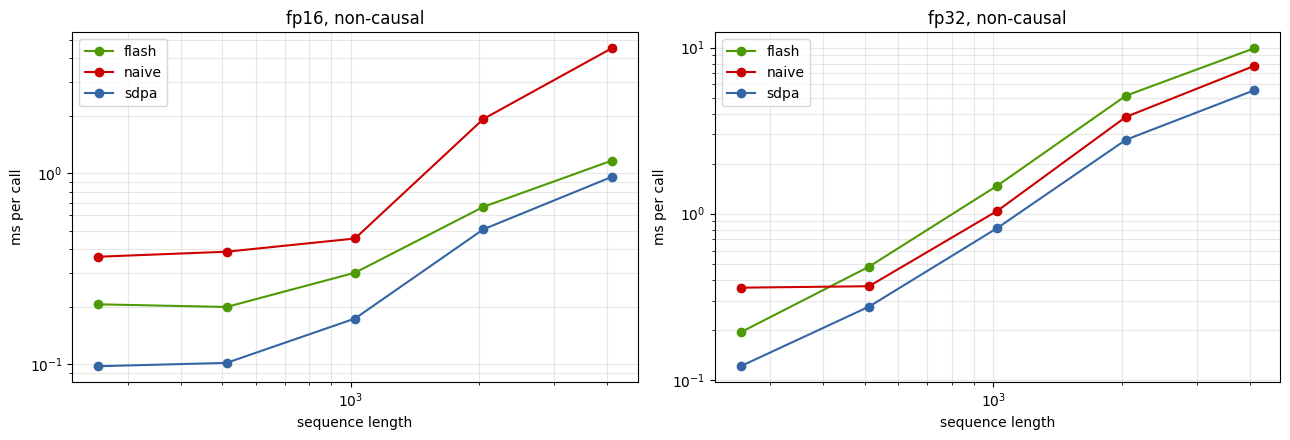

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = {"sdpa": "#3465a4", "naive": "#cc0000", "flash": "#4e9a06"}

for ax, dtype_name in zip(axes, ("fp16", "fp32"), strict=True):
    sub = df[(df.dtype == dtype_name) & (df.causal == "no")]
    for variant, g in sub.groupby("variant"):
        g = g.sort_values("seq_len")
        ax.plot(g.seq_len, g.ms, "o-", label=variant, color=colors[variant])
    ax.set(xlabel="sequence length", ylabel="ms per call",
           title=f"{dtype_name}, non-causal", xscale="log", yscale="log")
    ax.grid(alpha=.3, which="both")
    ax.legend()
fig.tight_layout()

## Throughput

Attention is compute-bound, so TFLOP/s over the two matmuls (QK^T and P@V) is the
metric that means something here. A bytes-moved model would not: not
materialising the N x N intermediate is the entire point of the algorithm.

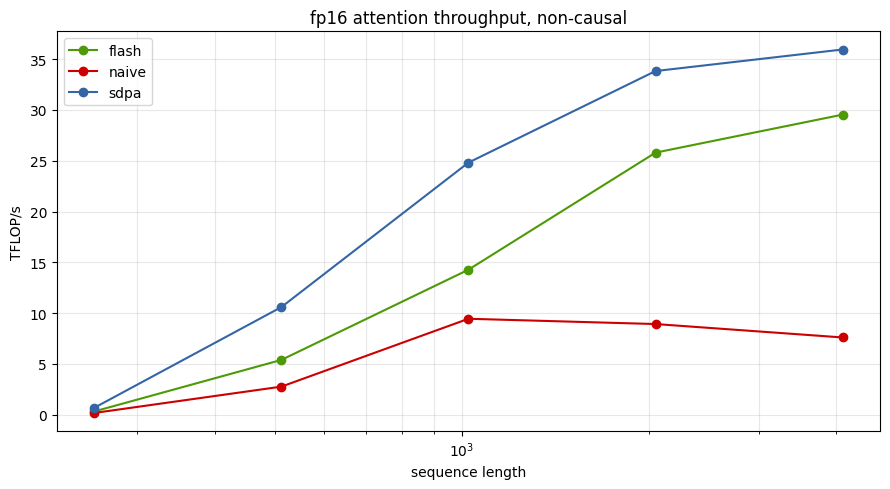

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
sub = df[(df.dtype == "fp16") & (df.causal == "no")]
for variant, g in sub.groupby("variant"):
    g = g.sort_values("seq_len")
    ax.plot(g.seq_len, g.tflops, "o-", label=variant, color=colors[variant])
ax.set(xlabel="sequence length", ylabel="TFLOP/s", xscale="log",
       title="fp16 attention throughput, non-causal")
ax.grid(alpha=.3, which="both")
ax.legend()
fig.tight_layout()

## Speedup over the naive implementation

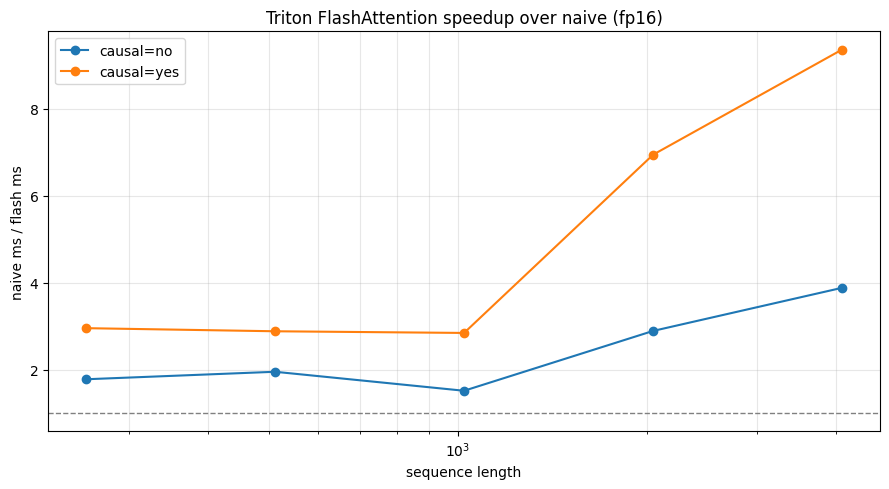

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for causal in ("no", "yes"):
    sub = df[(df.dtype == "fp16") & (df.causal == causal)]
    piv = sub.pivot_table(index="seq_len", columns="variant", values="ms")
    if {"naive", "flash"} <= set(piv.columns):
        ax.plot(piv.index, piv["naive"] / piv["flash"], "o-",
                label=f"causal={causal}")
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.set(xlabel="sequence length", ylabel="naive ms / flash ms",
       xscale="log", title="Triton FlashAttention speedup over naive (fp16)")
ax.grid(alpha=.3, which="both")
ax.legend()
fig.tight_layout()

## Summary

In [6]:
summary = (df[df.causal == "no"]
           .pivot_table(index=["dtype", "seq_len"], columns="variant", values="ms")
           .round(4))
summary["flash vs sdpa"] = (summary["sdpa"] / summary["flash"]).round(2)
summary["flash vs naive"] = (summary["naive"] / summary["flash"]).round(2)
summary

variant         flash   naive    sdpa  flash vs sdpa  flash vs naive
dtype seq_len                                                       
fp16  256      0.2054  0.3647  0.0973           0.47            1.78
      512      0.1989  0.3875  0.1013           0.51            1.95
      1024     0.3008  0.4545  0.1730           0.58            1.51
      2048     0.6659  1.9235  0.5079           0.76            2.89
      4096     1.1633  4.5157  0.9558           0.82            3.88
fp32  256      0.1932  0.3585  0.1207           0.62            1.86
      512      0.4798  0.3658  0.2757           0.57            0.76
      1024     1.4760  1.0410  0.8205           0.56            0.71
      2048     5.1270  3.8216  2.7829           0.54            0.75
      4096     9.8990  7.7526  5.5302           0.56            0.78